# Qwen3-VL-4B (Qwen3 Vision-Language) 사용 예제

[Qwen3-VL](https://huggingface.co/Qwen/Qwen3-VL-4B-Instruct)은 Alibaba Qwen 시리즈의 최신 **비전-언어 모델(VLM)** 입니다.
LLaVA와 달리 **한국어를 포함한 32개 언어** OCR·대화를 네이티브로 지원하며, 4B 파라미터로 **12GB VRAM** 환경에서도 실행하기 쉽습니다.

논문: [Qwen3 Technical Report](https://arxiv.org/abs/2505.09388)

이 노트북에서 다루는 내용:
1. Qwen3-VL-4B-Instruct 모델 로드 (`Qwen/Qwen3-VL-4B-Instruct`)
2. **이미지 설명** — 한국어·영어 단일 턴 질의응답
3. **Visual Question Answering (VQA)** — 한국어 질문으로 세부 정보 확인
4. **다중 턴 대화** — 맥락을 이어가며 후속 질문
5. **지시 따르기** — 객체 나열, 개수 세기 등
6. **배치 추론** — 여러 이미지에 동일 질문 적용
7. **LLaVA vs Qwen3-VL 비교 요약**

> 이전 노트북: `04_llava_example.ipynb` (LLaVA-7B, 영어 중심) · `05_llava_qlora_mini_train.ipynb` (QLoRA 학습)


## 1. 환경 설정

터미널에서 의존성을 설치합니다.

```bash
pip install -r requirements.txt
```

Qwen3-VL은 **transformers 4.57.0 이상**이 필요합니다.

```
torch>=2.0.0
transformers>=4.57.0
accelerate>=0.27.0
pillow>=10.0.0
matplotlib>=3.8.0
requests>=2.31.0
```

> **GPU 메모리 안내**: `Qwen3-VL-4B-Instruct`는 fp16/bf16 기준 약 **8~10GB VRAM**이면 추론 가능합니다 (RTX 3060 12GB 적합).
> 최초 실행 시 Hugging Face Hub에서 약 **8.9GB**를 다운로드합니다.


In [ ]:
# Qwen3-VL 추론에 필요한 패키지 
# %pip install -q "transformers>=4.57.0" "accelerate>=0.27.0"

In [1]:
import torch
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration


def setup_korean_font():
    """matplotlib 한글 폰트 설정 (Windows/Mac/Linux)"""
    for font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"):
        if font in {f.name for f in fm.fontManager.ttflist}:
            plt.rcParams["font.family"] = font
            break
    else:
        print("한글 폰트를 찾지 못했습니다. 제목 한글이 □로 표시될 수 있습니다.")
    plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지


setup_korean_font()

# GPU 사용 가능 시 cuda, 아니면 cpu
device = "cuda" if torch.cuda.is_available() else "cpu"
# RTX 30xx: fp16, Ampere 이상: bf16도 가능
if device == "cuda" and torch.cuda.is_bf16_supported():
    dtype = torch.bfloat16
else:
    dtype = torch.float16 if device == "cuda" else torch.float32

print(f"사용 디바이스: {device}")
print(f"연산 dtype: {dtype}")
print(f"matplotlib 폰트: {plt.rcParams['font.family']}")


사용 디바이스: cuda
연산 dtype: torch.bfloat16
matplotlib 폰트: ['Malgun Gothic']


## 2. Qwen3-VL 모델 로드

| 모델 | 파라미터 | 특징 |
|------|----------|------|
| `Qwen/Qwen3-VL-4B-Instruct` | 4B | **이 노트북 기본값** — 경량·한국어 지원 |
| `Qwen/Qwen3-VL-8B-Instruct` | 8B | 더 높은 품질, VRAM 16GB+ 권장 |
| `Qwen/Qwen3-VL-4B-Thinking` | 4B | 추론(Thinking) 강화 버전 |

Qwen3-VL은 `apply_chat_template()`으로 `<|im_start|>user` / `<|im_start|>assistant` 형식의 대화 프롬프트를 자동 구성합니다.


In [2]:
MODEL_ID = "Qwen/Qwen3-VL-4B-Instruct"

# device_map 사용 여부 판단 — accelerate 미설치 시 수동 .to(device)로 대체
try:
    import accelerate  # noqa: F401
    has_accelerate = True
except ImportError:
    has_accelerate = False
    print("accelerate 미설치: device_map 대신 model.to(device)를 사용합니다.")

load_kwargs = {
    "dtype": dtype,
    "low_cpu_mem_usage": True,  # RAM 절약형 로딩
}
if device == "cuda" and has_accelerate:
    load_kwargs["device_map"] = "auto"  # 가용 GPU에 자동 배치

# Hugging Face Hub에서 모델·전처리기 로드 (최초 실행 시 캐시에 다운로드)
model = Qwen3VLForConditionalGeneration.from_pretrained(MODEL_ID, **load_kwargs)
processor = AutoProcessor.from_pretrained(MODEL_ID)  # 이미지·텍스트 통합 전처리기

if device == "cpu" or not has_accelerate:
    model = model.to(device)

model.eval()  # 추론 모드: dropout 등 비활성화
print(f"모델 로드 완료: {MODEL_ID}")
print(f"모델 디바이스: {next(model.parameters()).device}")
# PC에서 다운로드 약 12분 소요 (약 8.8GB 크기)


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

모델 로드 완료: Qwen/Qwen3-VL-4B-Instruct
모델 디바이스: cuda:0


## 3. 샘플 이미지 준비

MS COCO val2017 CDN URL을 사용합니다. `04_llava_example.ipynb`와 동일한 샘플을 재사용합니다.


URL: http://images.cocodataset.org/val2017/000000543581.jpg
COCO image_id=543581, category=dog, size=(640, 427)
COCO 참고 캡션: A dog is sitting on the couch in a living room.


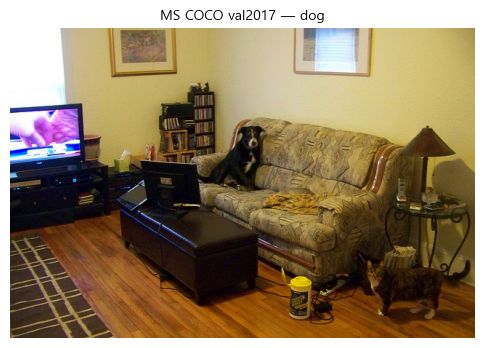

In [4]:
from dataclasses import dataclass

# COCO 공식 CDN — val2017 이미지를 개별 URL로 제공
COCO_IMAGE_BASE = "http://images.cocodataset.org/val2017/"

# MS COCO val2017 — 예제용 샘플만 URL로 지정 (전체 데이터셋 다운로드 불필요)
# file_name: COCO val2017 파일명, captions: 사람이 작성한 참고 캡션 (모델 결과 비교용)
COCO_SAMPLE_URLS: dict[str, dict] = {
    "dog": {
        "file_name": "000000543581.jpg",
        "image_id": 543581,
        "captions": [
            "A dog is sitting on the couch in a living room.",
            "A cute black dog sitting on the couch.",
        ],
    },
    "cat": {
        "file_name": "000000039769.jpg",
        "image_id": 39769,
        "captions": [
            "There are two cats laying down with two remotes",
            "Two cats sleeping with a remote control near each of them.",
        ],
    },
    "car": {
        "file_name": "000000527220.jpg",
        "image_id": 527220,
        "captions": [
            "A red car next to a gas station sign and parked blue and silver motorcycles.",
            "A red Ferrari at a gas station showing the gas prices and three mopeds",
        ],
    },
    "airplane": {
        "file_name": "000000001761.jpg",
        "image_id": 1761,
        "captions": [
            "Two planes flying in the sky over a bridge.",
            "Two planes fly over a bridge in Sydney, Australia, with the Sydney Opera House in the background.",
        ],
    },
}

COCO_SAMPLE_CATEGORIES = list(COCO_SAMPLE_URLS.keys())
_url_image_cache: dict[str, Image.Image] = {}  # 동일 URL 재요청 방지


@dataclass
class CocoSample:
    """COCO URL 샘플 1건 — 이미지 + 메타데이터"""
    image: Image.Image
    image_id: int
    category: str
    url: str
    captions: list[str]


def load_image_from_url(url: str) -> Image.Image:
    """URL에서 이미지 로드 (캐시 + User-Agent)"""
    if url in _url_image_cache:
        return _url_image_cache[url].copy()

    headers = {"User-Agent": "Qwen3-VL-Example-Notebook/1.0 (learning example)"}
    response = requests.get(url, timeout=30, headers=headers)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")
    _url_image_cache[url] = image
    return image.copy()


def load_coco_sample_meta(category: str) -> CocoSample:
    """COCO val2017 URL에서 샘플 이미지 + 참고 캡션 반환"""
    if category not in COCO_SAMPLE_URLS:
        raise ValueError(
            f"등록되지 않은 카테고리 '{category}'. "
            f"사용 가능: {', '.join(COCO_SAMPLE_CATEGORIES)}"
        )
    meta = COCO_SAMPLE_URLS[category]
    url = COCO_IMAGE_BASE + meta["file_name"]
    image = load_image_from_url(url)
    return CocoSample(
        image=image,
        image_id=meta["image_id"],
        category=category,
        url=url,
        captions=meta["captions"],
    )


def load_coco_samples(categories: list[str]) -> list[CocoSample]:
    """여러 카테고리 샘플을 한꺼번에 로드"""
    return [load_coco_sample_meta(cat) for cat in categories]


def show_image(image: Image.Image, title: str = ""):
    """이미지 1장 표시 (고해상도 COCO용 figsize=6)"""
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title, fontsize=10)
    plt.show()


# 예제용 강아지 이미지 로드 — 이후 섹션에서 `image`, `sample` 변수 재사용
sample = load_coco_sample_meta("dog")
image = sample.image
print(f"URL: {sample.url}")
print(f"COCO image_id={sample.image_id}, category={sample.category}, size={image.size}")
print(f"COCO 참고 캡션: {sample.captions[0]}")
show_image(image, f"MS COCO val2017 — {sample.category}")


## 4. 추론 헬퍼 함수

`apply_chat_template`으로 Qwen3 대화 형식을 맞추고, 입력 토큰 길이만큼 잘라 **assistant 응답만** 디코딩합니다.


In [5]:
def decode_generated(inputs, output_ids) -> str:
    """입력 프롬프트를 제외한 생성 토큰만 디코딩"""
    trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs["input_ids"], output_ids)
    ]
    texts = processor.batch_decode(
        trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )
    return texts[0].strip()


def _move_inputs_to_model(inputs: dict) -> dict:
    """텐서를 모델 디바이스·dtype에 맞게 이동"""
    model_device = next(model.parameters()).device
    moved = {}
    for key, value in inputs.items():
        if not hasattr(value, "to"):
            moved[key] = value
            continue
        if key == "pixel_values":
            moved[key] = value.to(model_device, dtype=dtype)  # 비전 입력은 fp16/bf16 맞춤
        else:
            moved[key] = value.to(model_device)
    return moved


def ask_qwen3_vl(
    question: str,
    *,
    image: Image.Image | None = None,
    image_url: str | None = None,
    conversation: list[dict] | None = None,
    max_new_tokens: int = 256,
    do_sample: bool = False,
    temperature: float = 0.7,
) -> str:
    """Qwen3-VL에 질문하고 assistant 응답 문자열을 반환.

    - `conversation`이 주어지면 다중 턴 대화로 처리
    - 그렇지 않으면 단일 턴: image_url 또는 image + question
    """
    if conversation is None:
        # 단일 턴: user 메시지에 이미지 + 텍스트 질문 구성
        content = []
        if image_url:
            content.append({"type": "image", "url": image_url})
        elif image is not None:
            content.append({"type": "image", "image": image})
        else:
            raise ValueError("image 또는 image_url 중 하나는 필요합니다.")
        content.append({"type": "text", "text": question})
        conversation = [{"role": "user", "content": content}]

    # Qwen3 <|im_start|>user/assistant 형식으로 프롬프트 구성 + 토큰화
    inputs = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,  # 마지막에 "<|im_start|>assistant" 추가
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = _move_inputs_to_model(inputs)

    generate_kwargs = {"max_new_tokens": max_new_tokens}
    if do_sample:
        generate_kwargs.update({"do_sample": True, "temperature": temperature})

    with torch.no_grad():
        output_ids = model.generate(**inputs, **generate_kwargs)

    return decode_generated(inputs, output_ids)


print("헬퍼 함수 준비 완료")


헬퍼 함수 준비 완료


## 5. 이미지 설명 (한국어 단일 턴)

Qwen3-VL은 **한국어 질문·답변**을 네이티브로 처리합니다. LLaVA와 달리 별도 번역 없이 바로 사용할 수 있습니다.


질문: 이 이미지를 자세히 한국어로 설명해 주세요.
Qwen3-VL 답변:
이 이미지는 따뜻한 조명 아래, 편안한 가정의 거실을 보여줍니다. 중앙에는 패턴이 있는 베이지색 소파가 있고, 그 위에는 검은색과 흰색이 섞인 강아지가 앉아 있으며, 눈을 반짝이며 캐리어처럼 보이는 것을 바라보고 있습니다. 소파 옆에는 갈색과 검은색이 섞인 고양이가 바닥에 서 있으며, 그 고양이는 소파의 뒷부분을 향해 걸어가고 있는 모습입니다.

소파 앞에는 검은색 가죽 소파 테이블이 있고, 그 위에는 노트북이 놓여 있습니다. 테이블 옆에는 TV가 있고, TV 화면에는 손이 보이는 영상이 나오고 있습니다. TV 아래에는 검은색 TV 서랍장이 있고, 그 옆에는 책장이 놓여 있으며, 책장 위에는 여러 권의 책과 디스크가 쌓여 있습니다.

소파 옆에는 작은 원형 테이블이

COCO 참고 캡션(영어): A dog is sitting on the couch in a living room.


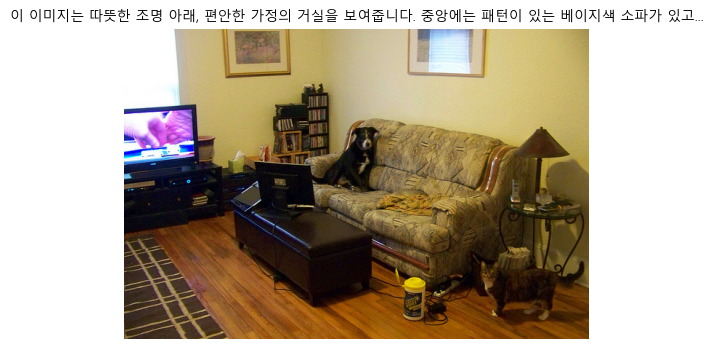

In [6]:
# 한국어 이미지 설명 — Qwen3-VL의 다국어 강점 확인
question = "이 이미지를 자세히 한국어로 설명해 주세요."
answer = ask_qwen3_vl(question, image_url=sample.url, max_new_tokens=256)

print(f"질문: {question}")
print(f"Qwen3-VL 답변:\n{answer}")
print(f"\nCOCO 참고 캡션(영어): {sample.captions[0]}")
show_image(image, answer[:60] + ("..." if len(answer) > 60 else ""))


## 6. Visual Question Answering (한국어 VQA)

같은 이미지에 여러 한국어 질문을 던져 세부 정보를 확인합니다.


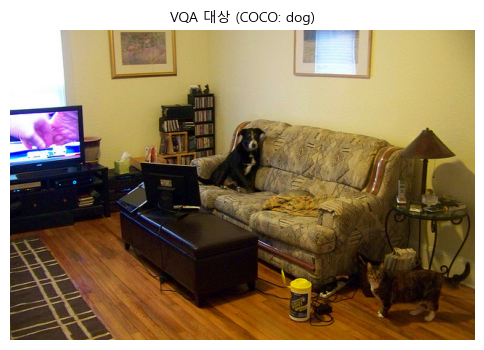

한국어 VQA 결과:
  Q: 이 사진에 어떤 동물이 있나요?
  A: 이 사진에는 **강아지**와 **고양이**가 있습니다.

- **강아지**: 소파 위에 앉아 있으며, 검은색과 흰색의 털을 가지고 있습니다.  
- **고양이**: 소파 앞에 서 있으며, 갈색과 검은색의 줄무늬 털을 가지고 있습니다.

두 동물 모두 사진 속에서 잘 보입니다.

  Q: 동물은 어디에 앉아 있나요?
  A: 이 사진에서 동물은 **소파 위**에 앉아 있습니다.

- **동물의 종류**: 검은색과 흰색이 섞인 **강아지**입니다.
- **위치**: 중앙에 있는 **패턴이 있는 소파** 위에 앉아 있으며, 소파의 왼쪽(사진에서 보면 오른쪽)에 있습니다.
- **상황**: 강아지는 소파에 앉아 있고, 몸을 앞으로 기울여 화면을 바라보는 듯한 자세를 취하고 있습니다.

또

  Q: 강아지가 혼자인가요?
  A: 네, 사진 속 강아지는 혼자 있습니다.  
강아지는 소파 위에 앉아 있으며, 주변에는 다른 동물이나 사람의 모습이 보이지 않습니다.  
그리고 사진 속에는 고양이도 있지만, 그는 강아지와는 별개로 소파 옆에 서 있습니다.  
따라서 강아지는 혼자 있는 것으로 보입니다.

  Q: 강아지의 주된 색깔은 무엇인가요?
  A: 강아지의 주된 색깔은 **검정**입니다.  
그리고 몸통과 얼굴에는 **흰색**이 섞여 있으며, 눈과 귀 주변에는 **검은색**이 더 강조되어 있습니다.  
전반적으로 검정과 흰색이 조합된 **갈색-검정-흰색**의 혼합 색상으로 보입니다.

하지만 문제에서 “주된 색깔”을 묻고 있으므로, 가장 두드러지는 색상은 **검정**입니다.

**정



In [7]:
# 같은 이미지에 여러 한국어 질문 — VQA(Visual Question Answering) 데모
questions = [
    "이 사진에 어떤 동물이 있나요?",
    "동물은 어디에 앉아 있나요?",
    "강아지가 혼자인가요?",
    "강아지의 주된 색깔은 무엇인가요?",
]

show_image(image, f"VQA 대상 (COCO: {sample.category})")
print("한국어 VQA 결과:")
for q in questions:
    ans = ask_qwen3_vl(q, image_url=sample.url, max_new_tokens=128)
    print(f"  Q: {q}")
    print(f"  A: {ans}")
    print()


## 7. 다중 턴 대화

첫 턴에서 이미지를 보여준 뒤, 이후 턴에서는 텍스트만으로 후속 질문을 이어갑니다.


In [8]:
# 첫 턴: 이미지 + 질문 (이후 턴은 텍스트만으로 맥락 유지)
conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": sample.url},
            {"type": "text", "text": "이 사진에 보이는 것을 간단히 한국어로 설명해 주세요."},
        ],
    },
]

first_answer = ask_qwen3_vl("", conversation=conversation, max_new_tokens=128)
print(f"[턴 1] A: {first_answer}")

# assistant 응답을 히스토리에 추가한 뒤 후속 질문
conversation.extend([
    {"role": "assistant", "content": [{"type": "text", "text": first_answer}]},
    {"role": "user", "content": [{"type": "text", "text": "강아지는 무엇을 하고 있나요?"}]},
])

second_answer = ask_qwen3_vl("", conversation=conversation, max_new_tokens=128)
print(f"[턴 2] Q: 강아지는 무엇을 하고 있나요?")
print(f"[턴 2] A: {second_answer}")

# 세 번째 턴: 추론이 필요한 개방형 질문
conversation.extend([
    {"role": "assistant", "content": [{"type": "text", "text": second_answer}]},
    {
        "role": "user",
        "content": [
            {
                "type": "text",
                "text": "반려동물 입양 사이트에 올리기 좋은 사진일까요? 이유도 알려주세요.",
            }
        ],
    },
])

third_answer = ask_qwen3_vl("", conversation=conversation, max_new_tokens=200)
print(f"[턴 3] Q: 반려동물 입양 사이트에 올리기 좋은 사진일까요?")
print(f"[턴 3] A: {third_answer}")


[턴 1] A: 이 사진은 거실을 보여줍니다. 소파에 앉아 있는 검은색 강아지와 바닥에 서 있는 고양이가 보입니다. TV는 켜져 있고, 소파 옆에는 램프와 작은 테이블이 있습니다. 바닥에는 나무 바닥과 체크무늬 카펫이 있고, 소파 옆에는 검은색 가죽 테이블이 있습니다.
[턴 2] Q: 강아지는 무엇을 하고 있나요?
[턴 2] A: 사진 속 강아지는 **소파에 앉아 있고, 옆에 있는 TV를 보고 있는 것처럼 보입니다.**  
강아지는 TV를 바라보며 편안하게 앉아 있어, TV 속 내용에 관심을 가지고 있는 듯한 모습입니다.  
그의 눈은 TV 방향을 향하고 있으며, 몸은 소파에 안락하게 기대어 있어 **휴식 중인 듯한 자세**를 취하고 있습니다.
[턴 3] Q: 반려동물 입양 사이트에 올리기 좋은 사진일까요?
[턴 3] A: 네, **이 사진은 반려동물 입양 사이트에 올리기 좋은 사진입니다.**  
아래는 그 이유입니다:

---

### ✅ **1. 감정을 전달하는 자연스러운 모습**
- 강아지는 **자연스럽게 소파에 앉아 있고**, TV를 바라보는 모습으로 **편안하고 평온한 분위기를** 전달합니다.
- 이는 입양자에게 “이 강아지는 집에 들어오면 편안하게 살 수 있을 거야”라는 **감정적 연결**을 제공합니다.

---

### ✅ **2. 매력적인 포즈와 표정**
- 강아지는 **눈을 뜨고 TV를 바라보는 것처럼 보이지만**, 실제는 **입양자에게 귀여움을 전달하는 포즈**입니다.
- **눈을 뜬 상태**


## 8. 지시 따르기 — 다른 이미지로 추론 테스트

고양이 이미지로 **객체 나열**, **개수 세기** 등 구조화된 지시를 수행합니다.


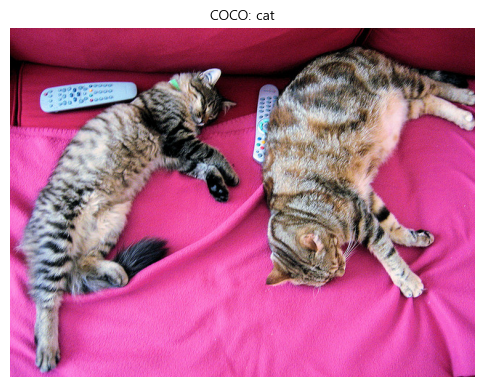

지시: 이 이미지에서 식별할 수 있는 모든 사물을 나열해 주세요.
응답: 이 이미지에서 식별할 수 있는 사물은 다음과 같습니다:

- **고양이 1마리** (왼쪽): 털이 갈색과 검은색 줄무늬가 있는 고양이. 몸을 뒤로 기울이고, 다리와 꼬리를 펴서 편안하게 누워 있습니다. 목에는 녹색 끈이 걸려 있습니다.
- **고양이 2마리** (오른쪽): 털이 갈색과 검은색 줄무늬가 있는 고양이. 몸을 앞으로 기울이고, 눈을 감아서 편안하게 누워 있습니다.
- **리모컨 1개** (왼쪽): 회색의 리모컨. 고양이 1마리 옆에 놓여 있습니다.
- **리모컨 2개** (오른쪽): 흰색과 파란색이 조합된 리모컨. 고양이 2마리 옆에 놓여 있습니다.
- **소파** (배경): 분홍색 소파. 고양이들이 누
------------------------------------------------------------
지시: 고양이가 몇 마리 보이나요? 숫자만 답해 주세요.
응답: 2
------------------------------------------------------------
지시: 전자기기가 있나요? 있다면 이름을 알려주세요.
응답: 네, 전자기기가 있습니다. 이름은 **리모컨**입니다.

이미지에 보이는 두 개의 장치는 모두 **리모컨**으로, TV나 스마트 TV 등 전자기기의 원격 제어용으로 사용됩니다. 한 개는 흰색으로, 다른 하나는 파란색과 흰색이 섞인 디자인입니다. 두 리모컨은 분명히 총 2개이며, 그 옆에 누워 있는 고양이들이 둘 다 편안하게 잠들고
------------------------------------------------------------


In [9]:
cat_sample = load_coco_sample_meta("cat")
show_image(cat_sample.image, f"COCO: {cat_sample.category}")

# 구조화된 지시 — 객체 나열, 개수 세기, 특정 카테고리 탐지
tasks = [
    ("이 이미지에서 식별할 수 있는 모든 사물을 나열해 주세요.", 256),
    ("고양이가 몇 마리 보이나요? 숫자만 답해 주세요.", 32),
    ("전자기기가 있나요? 있다면 이름을 알려주세요.", 128),
]

for prompt, max_tokens in tasks:
    result = ask_qwen3_vl(prompt, image_url=cat_sample.url, max_new_tokens=max_tokens)
    print(f"지시: {prompt}")
    print(f"응답: {result}")
    print("-" * 60)


## 9. 배치 추론

여러 이미지에 동일한 질문을 한꺼번에 적용합니다. 배치 생성 시 `padding_side="left"`를 설정합니다.


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


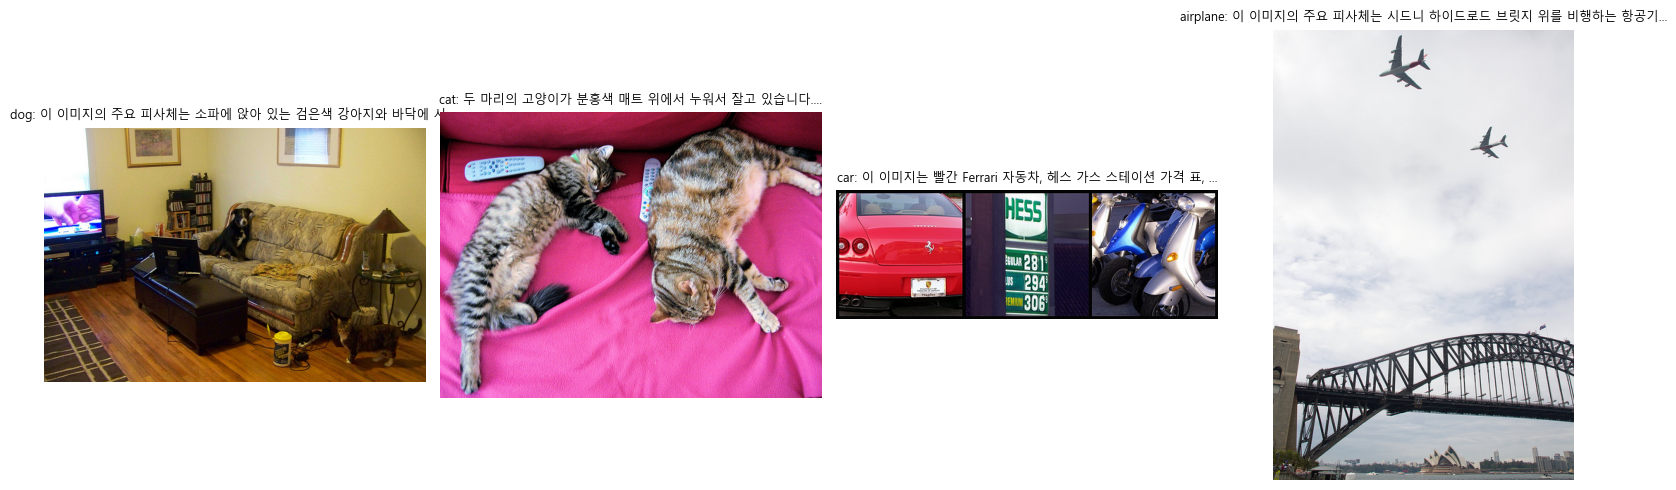

공통 질문: 이 이미지의 주요 피사체는 무엇인가요? 한 문장으로 답해 주세요.
  [dog] 이 이미지의 주요 피사체는 소파에 앉아 있는 검은색 강아지와 바닥에 서 있는 고양이입니다.
  [cat] 두 마리의 고양이가 분홍색 매트 위에서 누워서 잘고 있습니다.
  [car] 이 이미지는 빨간 Ferrari 자동차, 헤스 가스 스테이션 가격 표, 그리고 파란색 스쿠터를 동시에 보여주는 세 개의 사진을 합쳐진 콜라주입니다.
  [airplane] 이 이미지의 주요 피사체는 시드니 하이드로드 브릿지 위를 비행하는 항공기들입니다.


In [10]:
# 배치 생성 시 왼쪽 패딩이 디코더 정확도에 유리 (transformers 권장)
processor.tokenizer.padding_side = "left"

batch_samples = load_coco_samples(["dog", "cat", "car", "airplane"])
question = "이 이미지의 주요 피사체는 무엇인가요? 한 문장으로 답해 주세요."

# 이미지마다 동일 질문의 대화 리스트 구성
conversations = []
for s in batch_samples:
    conversations.append([
        {
            "role": "user",
            "content": [
                {"type": "image", "url": s.url},
                {"type": "text", "text": question},
            ],
        }
    ])

inputs = processor.apply_chat_template(
    conversations,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    padding=True,  # 배치 내 시퀀스 길이 맞춤
    return_tensors="pt",
)
inputs = _move_inputs_to_model(inputs)

with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=128)

# 배치별로 입력 길이만큼 trim 후 디코딩
decoded_batch = [
    decode_generated({"input_ids": inputs["input_ids"][i : i + 1]}, output_ids[i : i + 1])
    for i in range(len(batch_samples))
]

# 4장 이미지 + 답변을 한눈에 비교
fig, axes = plt.subplots(1, len(batch_samples), figsize=(16, 5))
if len(batch_samples) == 1:
    axes = [axes]

for ax, s, answer in zip(axes, batch_samples, decoded_batch):
    ax.imshow(s.image)
    ax.axis("off")
    ax.set_title(f"{s.category}: {answer[:40]}...", fontsize=9)

plt.tight_layout()
plt.show()

print(f"공통 질문: {question}")
for s, answer in zip(batch_samples, decoded_batch):
    print(f"  [{s.category}] {answer}")


## 10. 영어 질의 비교 (선택)

동일 이미지에 영어 질문을 던져 다국어 처리 능력을 확인합니다.


In [11]:
# 동일 이미지에 영어 질문 — 다국어 처리 능력 확인
en_question = "Describe this image in one concise English sentence."
en_answer = ask_qwen3_vl(en_question, image_url=sample.url, max_new_tokens=128)

print(f"English Q: {en_question}")
print(f"English A: {en_answer}")


English Q: Describe this image in one concise English sentence.
English A: In a cozy living room with hardwood floors, a black and white dog lounges on a patterned couch while a tabby cat walks nearby, a TV displays a show, and a laptop sits on a black ottoman.


## 11. LLaVA vs Qwen3-VL 비교 요약

| 항목 | LLaVA-7B (04번) | Qwen3-VL-4B (이 노트북) |
|------|-----------------|-------------------------|
| **핵심 구조** | CLIP-ViT + Vicuna LLM | Interleaved-MRoPE + DeepStack ViT + Qwen3 LLM |
| **파라미터** | 7B | 4B |
| **VRAM (fp16)** | ~14GB | ~8~10GB |
| **한국어 질문** | △ (영어 중심) | ✓ (네이티브 지원) |
| **한국어 답변** | △ | ✓ |
| **다중 턴 대화** | ✓ | ✓ |
| **OCR / 문서** | 제한적 | 32개 언어 OCR 강화 |
| **적합 용도** | 영어 복잡 추론·대화 | **한국어 VLM**, 경량 배포, OCR·문서 이해 |

**선택 가이드**
- **한국어 VQA·캡션** → Qwen3-VL (이 노트북)
- **영어 중심 다중 턴 대화·학습 파이프라인 체험** → LLaVA (`04`, `05`번)
- **분류·검색·유사도** → CLIP (`01_clip_example.ipynb`)
- **한국어 VLM 파인튜닝** → `vlm101-sft-hands-on-main/ko_sft_lora_qwen2.5vl.ipynb` 참고
